In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

%matplotlib inline

In [2]:
climate_df = pd.read_csv(
    "../data/processed/climate_trend_clean.csv"
)

climate_df.head()

,Year,J-D
0,1880,-0.18
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.29


In [3]:
climate_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    147 non-null    int64  
 1   J-D     146 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 2.4 KB


In [4]:
summary = climate_df.describe()

summary

,Year,J-D
count,147.000000,146.000000
mean,1953.000000,0.082123
std,42.579338,0.401860
min,1880.000000,-0.490000
25%,1916.500000,-0.200000
50%,1953.000000,-0.030000
75%,1989.500000,0.317500
max,2026.000000,1.280000


In [6]:
from pathlib import Path

Path("../outputs/tables").mkdir(parents=True, exist_ok=True)
summary.to_csv("../outputs/tables/summary_statistics.csv")


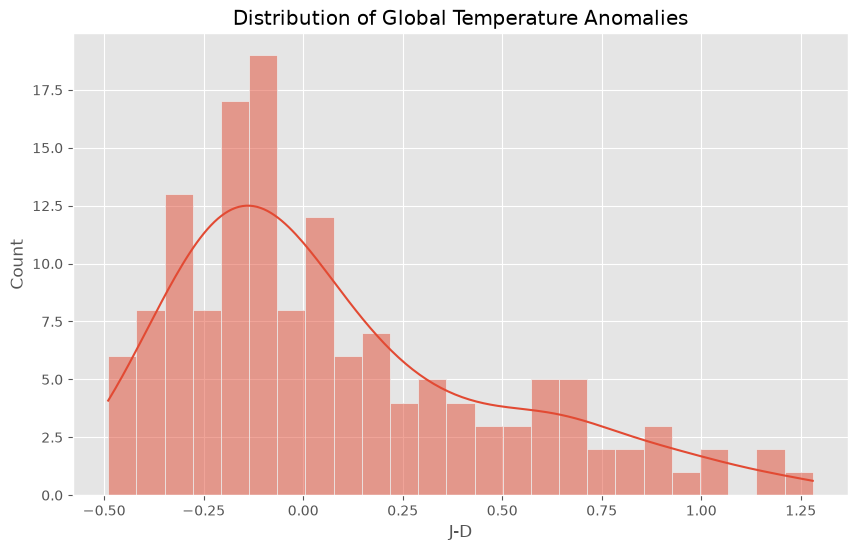

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(
    climate_df["J-D"],
    bins=25,
    kde=True
)

plt.title("Distribution of Global Temperature Anomalies")

Path("../outputs/graphs").mkdir(parents=True, exist_ok=True)
plt.savefig(
    "../outputs/graphs/temperature_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

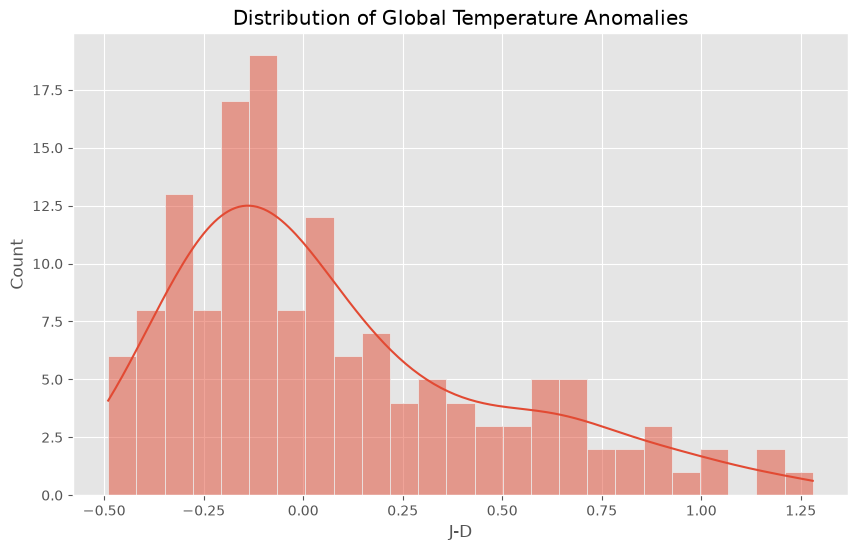

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    climate_df["J-D"].dropna(),
    bins=25,
    kde=True
)

plt.title("Distribution of Global Temperature Anomalies")

Path("../outputs/graphs").mkdir(parents=True, exist_ok=True)
plt.savefig(
    "../outputs/graphs/temperature_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

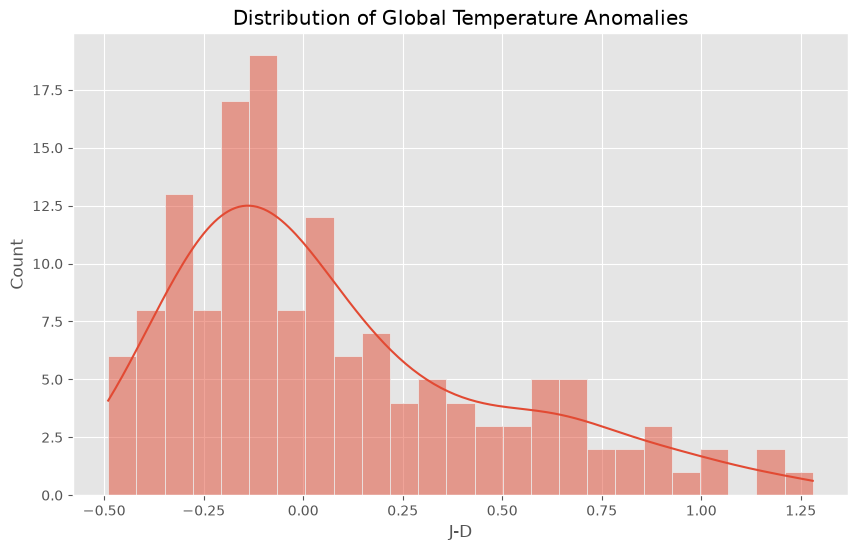

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    climate_df["J-D"].dropna(),
    bins=25,
    kde=True
)

plt.title("Distribution of Global Temperature Anomalies")

plt.savefig(
    "../outputs/graphs/temperature_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

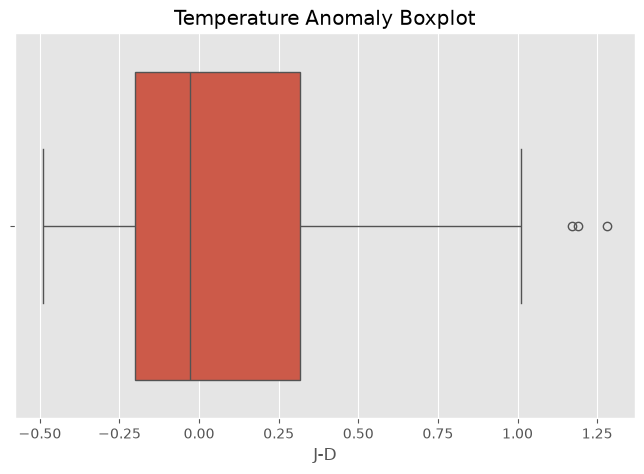

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x=climate_df["J-D"].dropna())

plt.title("Temperature Anomaly Boxplot")

plt.savefig(
    "../outputs/graphs/boxplot_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

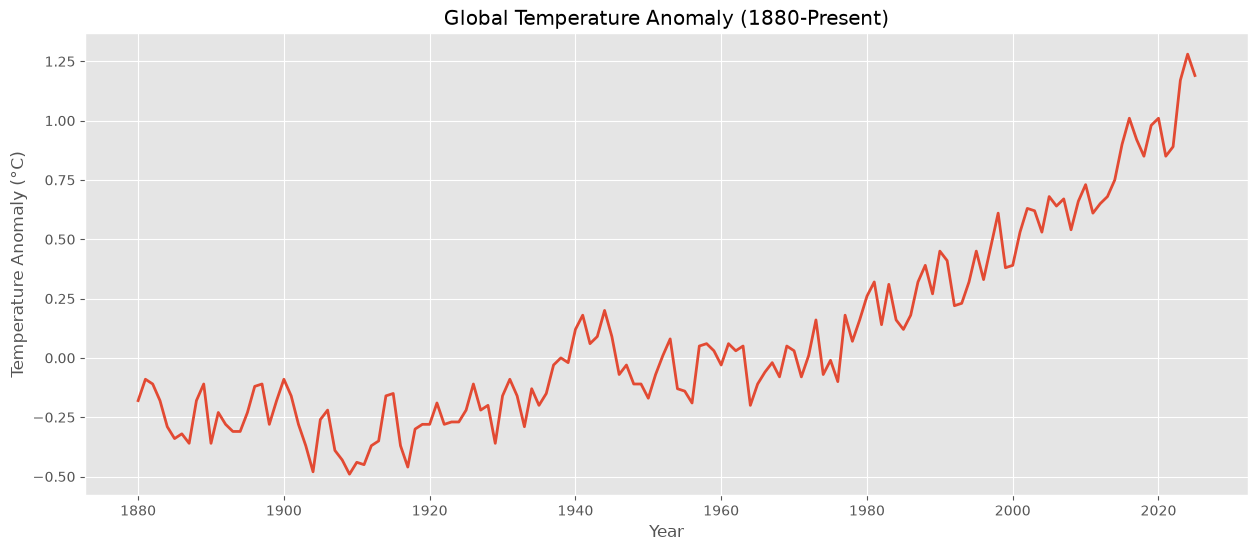

In [18]:
plt.figure(figsize=(15,6))

plt.plot(
    climate_df["Year"],
    climate_df["J-D"],
    linewidth=2
)

plt.title("Global Temperature Anomaly (1880-Present)")

plt.xlabel("Year")

plt.ylabel("Temperature Anomaly (°C)")

plt.grid(True)

plt.savefig(
    "../outputs/graphs/temperature_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
climate_df["Rolling_Avg"] = (
    climate_df["J-D"]
    .rolling(window=10)
    .mean()
)

<Figure size 1500x600 with 0 Axes>

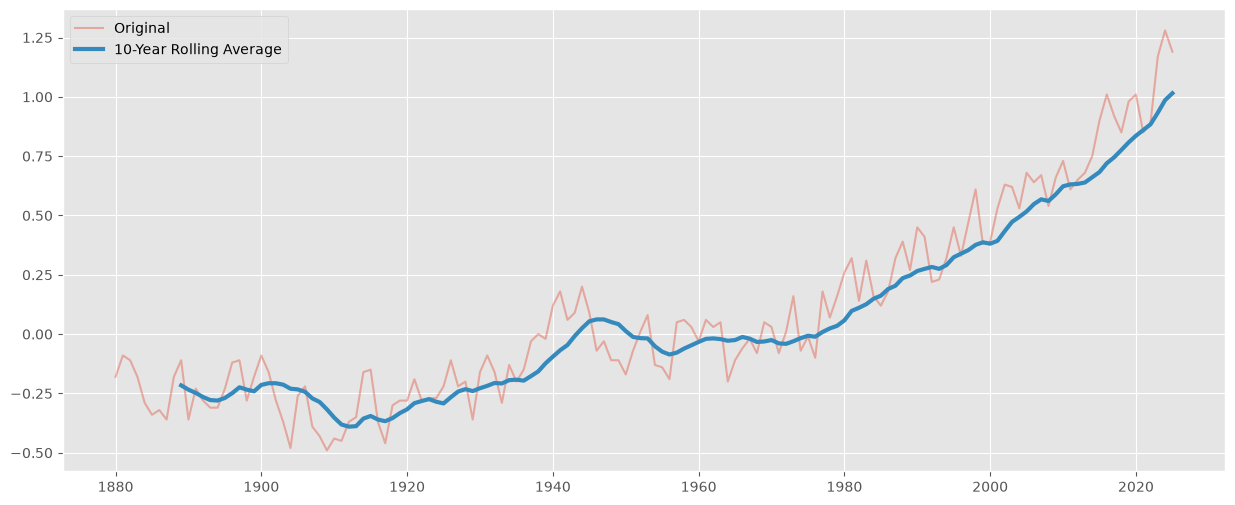

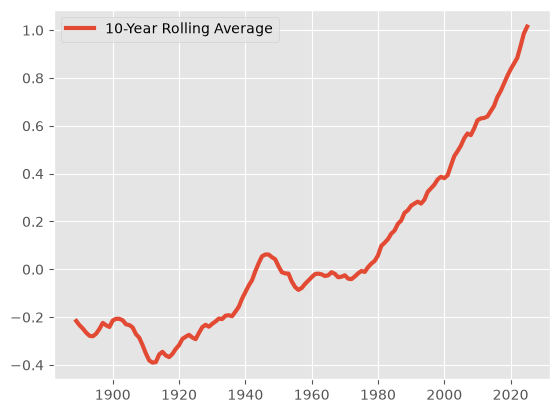

In [22]:
plt.figure(figsize=(15,6))

plt.figure(figsize=(15,6))

plt.plot(
    climate_df["Year"],
    climate_df["J-D"],
    alpha=0.4,
    label="Original"
)

plt.plot(
    climate_df["Year"],
    climate_df["Rolling_Avg"],
    linewidth=3,
    label="10-Year Rolling Average"
)

plt.legend()
plt.grid(True)

plt.savefig(
    "../outputs/graphs/rolling_average.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.plot(
    climate_df["Year"],
    climate_df["Rolling_Avg"],
    linewidth=3,
    label="10-Year Rolling Average"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "../outputs/graphs/rolling_average.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
top_hot = (
    climate_df
    .sort_values(
        "J-D",
        ascending=False
    )
    .head(10)
)

top_hot

,Year,J-D,Rolling_Avg
144,2024,1.28,0.986
145,2025,1.19,1.015
143,2023,1.17,0.933
136,2016,1.01,0.720
140,2020,1.01,0.836
139,2019,0.98,0.808
137,2017,0.92,0.745
135,2015,0.90,0.683
142,2022,0.89,0.884
141,2021,0.85,0.860


In [25]:
top_hot.to_csv(
    "../outputs/tables/top10_hottest_years.csv",
    index=False
)

In [27]:
top_cold = (
    climate_df
    .sort_values("J-D")
    .head(10)
)

top_cold

top_cold

,Year,J-D,Rolling_Avg
29,1909,-0.49,-0.317
24,1904,-0.48,-0.230
37,1917,-0.46,-0.367
31,1911,-0.45,-0.381
30,1910,-0.44,-0.352
28,1908,-0.43,-0.286
27,1907,-0.39,-0.271
23,1903,-0.37,-0.213
32,1912,-0.37,-0.390
36,1916,-0.37,-0.360


In [28]:
top_hot.to_csv(
    "../outputs/tables/top10_hottest_years.csv",
    index=False
)

In [32]:
print(
    f"Average Temperature Anomaly : {climate_df['J-D'].mean():.2f}"
)

print(
    f"Maximum Temperature Anomaly : {climate_df['J-D'].max():.2f}"
)

print(
    f"Minimum Temperature Anomaly : {climate_df['J-D'].min():.2f}"
)

print(
    f"Warmest Year : {top_hot.iloc[0]['Year']}"
)

print(
    f"Maximum Temperature Anomaly : {climate_df['J-D'].max():.2f}"
)

print(
    f"Minimum Temperature Anomaly : {climate_df['J-D'].min():.2f}"
)

print(
    f"Warmest Year : {top_hot.iloc[0]['Year']}"
)

Average Temperature Anomaly : 0.08
Maximum Temperature Anomaly : 1.28
Minimum Temperature Anomaly : -0.49
Warmest Year : 2024.0
Maximum Temperature Anomaly : 1.28
Minimum Temperature Anomaly : -0.49
Warmest Year : 2024.0


In [34]:
top_cold = (
    climate_df
    .sort_values("J-D")
    .head(10)
)

top_cold

top_cold

,Year,J-D,Rolling_Avg
29,1909,-0.49,-0.317
24,1904,-0.48,-0.230
37,1917,-0.46,-0.367
31,1911,-0.45,-0.381
30,1910,-0.44,-0.352
28,1908,-0.43,-0.286
27,1907,-0.39,-0.271
23,1903,-0.37,-0.213
32,1912,-0.37,-0.390
36,1916,-0.37,-0.360


In [35]:
top_cold.to_csv(
    "../outputs/tables/top10_coldest_years.csv",
    index=False
)

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.eda import load_clean_data

climate_df = load_clean_data(str(project_root / "data" / "processed" / "climate_trend_clean.csv"))

%matplotlib inline

plt.rcParams["figure.figsize"] = (12,6)

%matplotlib inline

plt.rcParams["figure.figsize"] = (12,6)

In [39]:
climate_df = load_clean_data(
    "../data/processed/climate_trend_clean.csv"
)

climate_df.head()

,Year,J-D
0,1880,-0.18
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.29


In [40]:
climate_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    147 non-null    int64  
 1   J-D     146 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 2.4 KB


In [41]:
climate_df.shape

(147, 2)

In [42]:
climate_df.columns

Index(['Year', 'J-D'], dtype='str')

In [43]:
summary = climate_df.describe()

summary

,Year,J-D
count,147.000000,146.000000
mean,1953.000000,0.082123
std,42.579338,0.401860
min,1880.000000,-0.490000
25%,1916.500000,-0.200000
50%,1953.000000,-0.030000
75%,1989.500000,0.317500
max,2026.000000,1.280000


In [48]:
summary.to_csv(
    "../outputs/tables/summary_statistics.csv"
)

In [47]:
average = climate_df["J-D"].mean()

maximum = climate_df["J-D"].max()
minimum = climate_df["J-D"].min()

print(f"Average Temperature Anomaly : {average:.2f}")

print(f"Maximum Temperature Anomaly : {maximum:.2f}")

print(f"Minimum Temperature Anomaly : {minimum:.2f}")

Average Temperature Anomaly : 0.08
Maximum Temperature Anomaly : 1.28
Minimum Temperature Anomaly : -0.49


In [5]:
plt.figure(figsize=(10,6))

plt.figure(figsize=(10,6))

plt.hist(
    climate_df["J-D"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Global Temperature Anomalies")

plt.xlabel("Temperature Anomaly (°C)")

plt.ylabel("Number of Years")

plt.grid(alpha=0.3)

plt.savefig(
    "../outputs/graphs/temperature_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.title("Distribution of Global Temperature Anomalies")

plt.xlabel("Temperature Anomaly (°C)")

plt.ylabel("Number of Years")

plt.grid(alpha=0.3)

plt.savefig(
    "../outputs/graphs/temperature_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


NameError: name 'plt' is not defined

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [7]:
from pathlib import Path

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print(DATA_DIR)

..\data\processed


In [8]:
climate_df = pd.read_csv(DATA_DIR / "climate_trend_clean.csv")

climate_df.head()

,Year,J-D
0,1880,-0.18
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.29


In [9]:
print(climate_df.shape)
print(climate_df.dtypes)
print(climate_df.isnull().sum())

(147, 2)
Year      int64
J-D     float64
dtype: object
Year    0
J-D     1
dtype: int64


<Figure size 1000x600 with 0 Axes>

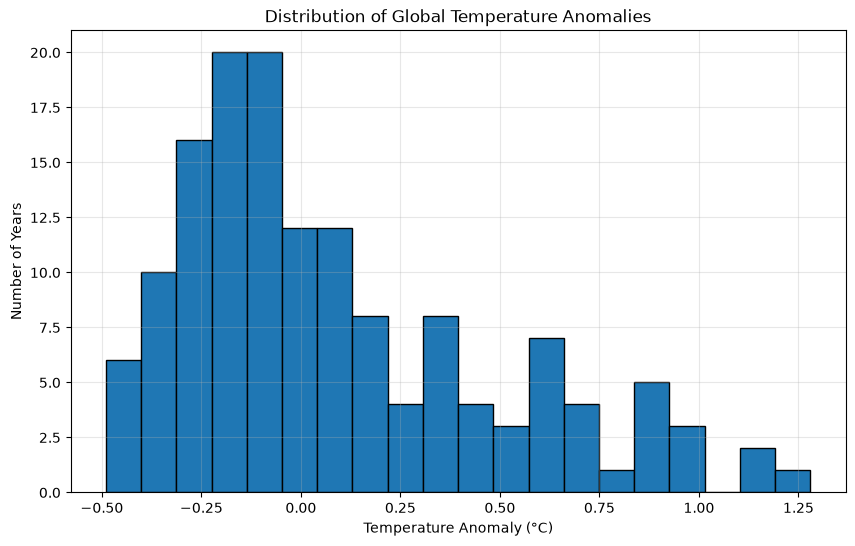

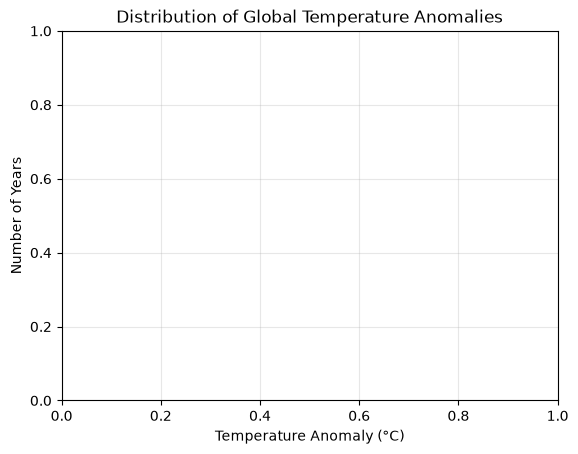

In [10]:
plt.figure(figsize=(10,6))

plt.figure(figsize=(10,6))

plt.hist(
    climate_df["J-D"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Global Temperature Anomalies")

plt.xlabel("Temperature Anomaly (°C)")

plt.ylabel("Number of Years")

plt.grid(alpha=0.3)

plt.savefig(
    "../outputs/graphs/temperature_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.title("Distribution of Global Temperature Anomalies")

plt.xlabel("Temperature Anomaly (°C)")

plt.ylabel("Number of Years")

plt.grid(alpha=0.3)

plt.savefig(
    "../outputs/graphs/temperature_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [14]:
climate_df.describe()


,Year,J-D
count,147.000000,146.000000
mean,1953.000000,0.082123
std,42.579338,0.401860
min,1880.000000,-0.490000
25%,1916.500000,-0.200000
50%,1953.000000,-0.030000
75%,1989.500000,0.317500
max,2026.000000,1.280000


In [18]:
print(climate_df.head())

print(climate_df.describe())

print(climate_df.dtypes)

print(climate_df.shape)

   Year   J-D
0  1880 -0.18
1  1881 -0.09
2  1882 -0.11
3  1883 -0.18
4  1884 -0.29
              Year         J-D
count   147.000000  146.000000
mean   1953.000000    0.082123
std      42.579338    0.401860
min    1880.000000   -0.490000
25%    1916.500000   -0.200000
50%    1953.000000   -0.030000
75%    1989.500000    0.317500
max    2026.000000    1.280000
Year      int64
J-D     float64
dtype: object
(147, 2)


In [20]:
print("Minimum:", climate_df["J-D"].min())
print("Maximum:", climate_df["J-D"].max())
print("Median :", climate_df["J-D"].median())

Minimum: -0.49
Maximum: 1.28
Median : -0.03


C:\Users\shravani2006\AppData\Local\Temp\ipykernel_10580\955902073.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


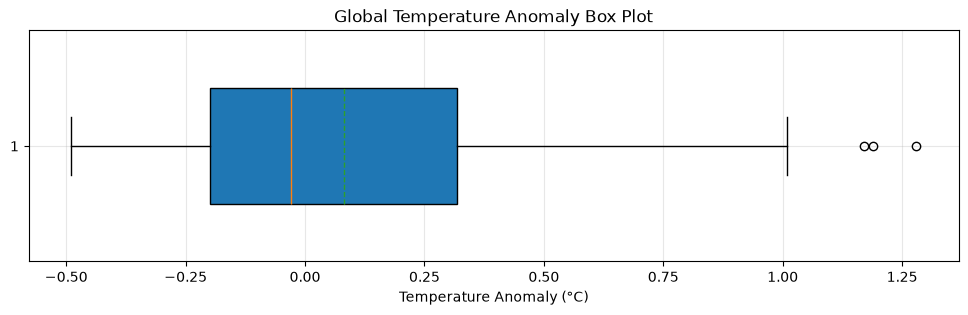

In [22]:
plt.figure(figsize=(12,3))

plt.boxplot(
    climate_df["J-D"].dropna(),
    vert=False,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    widths=0.5
)

plt.title("Global Temperature Anomaly Box Plot")

plt.xlabel("Temperature Anomaly (°C)")

plt.grid(alpha=0.3)

plt.show()

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

%matplotlib inline

plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (12,6)

In [5]:
from pathlib import Path

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print(DATA_DIR)

..\data\processed


In [ ]:
climate_df = pd.read_csv(DATA_DIR / "climate_trend_clean.csv")
climate_df.head()


NameError: name 'load_clean_data' is not defined